Using device: cuda


100%|██████████| 187M/187M [00:08<00:00, 22.3MB/s]
100%|██████████| 89.0M/89.0M [00:07<00:00, 11.8MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 220kB/s]


Train: 22644 | Val: 3996 | Test: 12630
Custom CNN — Trainable parameters: 629,291

Training on cuda for 30 epochs...

Epoch 01/30 | Train Loss 2.3678 Acc 0.3098 | Val Loss 1.4335 Acc 0.5025 | 20.4s
Epoch 02/30 | Train Loss 1.2938 Acc 0.5631 | Val Loss 0.7739 Acc 0.7387 | 20.1s
Epoch 03/30 | Train Loss 0.8712 Acc 0.6997 | Val Loss 0.5484 Acc 0.8153 | 19.0s
Epoch 04/30 | Train Loss 0.6313 Acc 0.7848 | Val Loss 0.3027 Acc 0.9099 | 21.2s
Epoch 05/30 | Train Loss 0.4963 Acc 0.8291 | Val Loss 0.2526 Acc 0.9227 | 19.4s
Epoch 06/30 | Train Loss 0.4202 Acc 0.8595 | Val Loss 0.1743 Acc 0.9472 | 20.6s
Epoch 07/30 | Train Loss 0.3570 Acc 0.8794 | Val Loss 0.1708 Acc 0.9540 | 19.4s
Epoch 08/30 | Train Loss 0.3104 Acc 0.8979 | Val Loss 0.1008 Acc 0.9700 | 20.2s
Epoch 09/30 | Train Loss 0.2683 Acc 0.9111 | Val Loss 0.1174 Acc 0.9665 | 21.3s
Epoch 10/30 | Train Loss 0.2527 Acc 0.9157 | Val Loss 0.0825 Acc 0.9792 | 20.1s
Epoch 11/30 | Train Loss 0.1798 Acc 0.9427 | Val Loss 0.0690 Acc 0.9812 | 20.3s
Ep

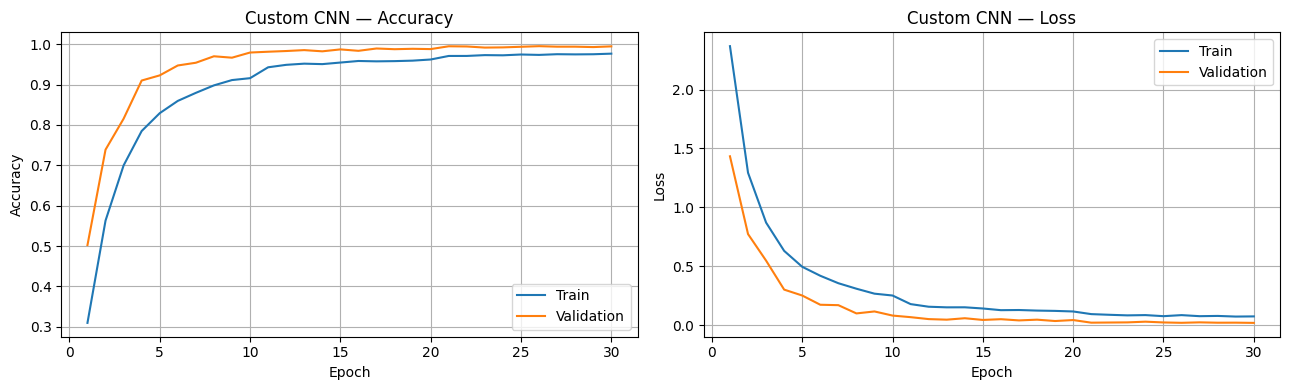

Saved: checkpoints/curves_cnn.png

Test Accuracy: 0.9709

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        60
           1     0.9917    0.9931    0.9924       720
           2     0.9868    0.9947    0.9907       750
           3     0.9817    0.9556    0.9685       450
           4     0.9938    0.9788    0.9863       660
           5     0.9364    0.9810    0.9581       630
           6     0.9795    0.9533    0.9662       150
           7     0.9823    0.9844    0.9834       450
           8     0.9840    0.9578    0.9707       450
           9     0.9755    0.9938    0.9845       480
          10     0.9955    0.9955    0.9955       660
          11     0.9709    0.9548    0.9628       420
          12     0.9984    0.9203    0.9578       690
          13     0.9612    0.9972    0.9789       720
          14     0.9963    1.0000    0.9982       270
          15     0.9091    1.0000    0.9524       210
          16     0.9933

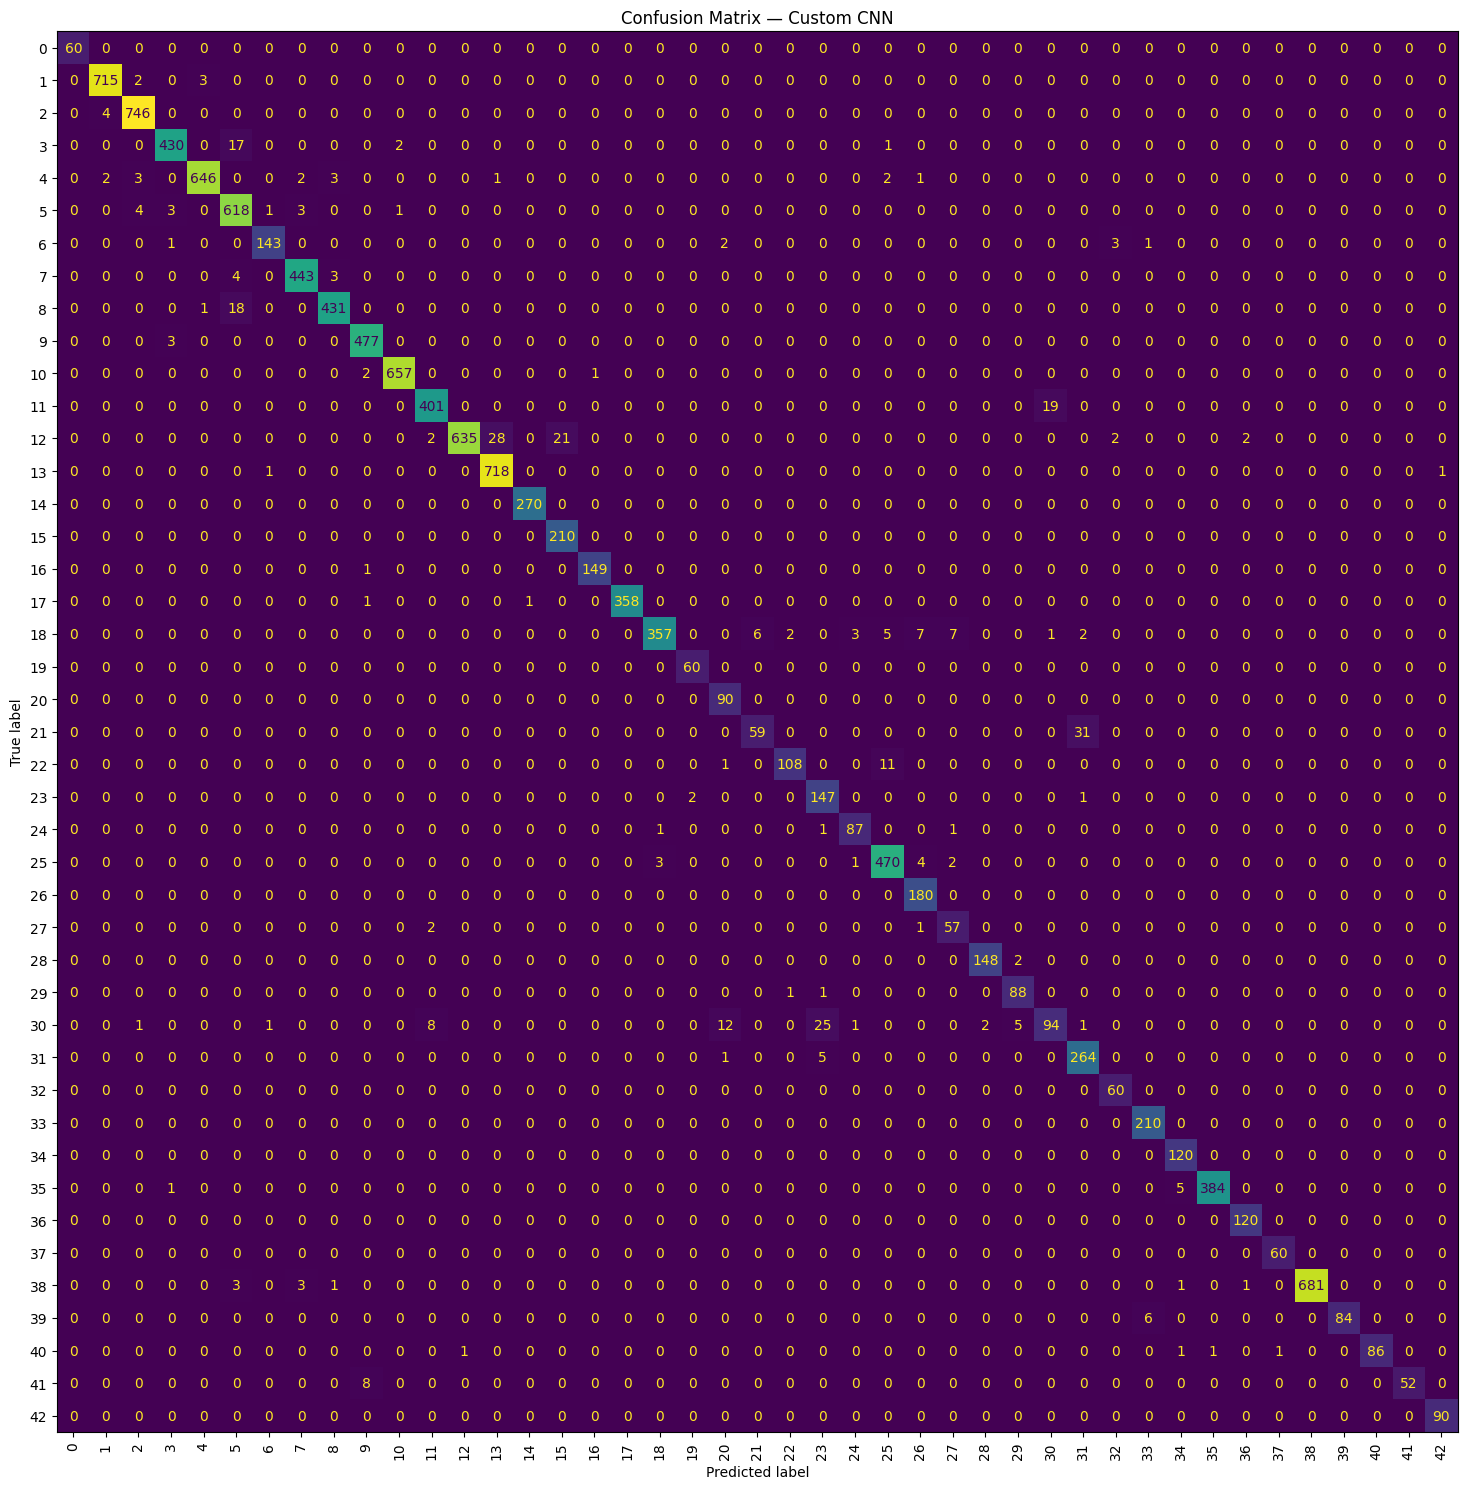

Saved: checkpoints/confusion_cnn.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done — check your downloads folder.


In [ ]:
# CS 5100 Final Project — Traffic Sign Recognition - Dhyey Jariwala

# ── Cell 1: Install & imports ─────────────────────────────────────
!pip install -q scikit-learn

import os, time, torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")  # should print: Using device: cuda
os.makedirs("checkpoints", exist_ok=True)


# ── Cell 2: Dataset & preprocessing ──────────────────────────────
IMG_SIZE    = 32
BATCH_SIZE  = 64
NUM_CLASSES = 43

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.3337, 0.3064, 0.3171),
                         (0.2672, 0.2564, 0.2629)),
])
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.3337, 0.3064, 0.3171),
                         (0.2672, 0.2564, 0.2629)),
])

train_full = datasets.GTSRB(root="./data", split="train", download=True, transform=train_transforms)
test_set   = datasets.GTSRB(root="./data", split="test",  download=True, transform=eval_transforms)

val_size  = int(0.15 * len(train_full))
train_set, val_set = random_split(train_full, [len(train_full) - val_size, val_size])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")


# ── Cell 3: Custom CNN architecture ───────────────────────────────
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
    )

class CustomCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3,  32),   # 32→16
            conv_block(32, 64),   # 16→8
            conv_block(64, 128),  #  8→4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

model = CustomCNN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom CNN — Trainable parameters: {total_params:,}")


# ── Cell 4: Training loop ─────────────────────────────────────────
EPOCHS    = 30
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if train: optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            n          += imgs.size(0)
    return total_loss / n, correct / n

print(f"\nTraining on {DEVICE} for {EPOCHS} epochs...\n")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader, train=True)
    vl_loss, vl_acc = run_epoch(model, val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "checkpoints/best_cnn.pth")

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f} | "
          f"{time.time()-t0:.1f}s")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")


# ── Cell 5: Accuracy & loss curves ───────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_range, history["train_acc"], label="Train")
ax1.plot(epochs_range, history["val_acc"],   label="Validation")
ax1.set_title("Custom CNN — Accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True)

ax2.plot(epochs_range, history["train_loss"], label="Train")
ax2.plot(epochs_range, history["val_loss"],   label="Validation")
ax2.set_title("Custom CNN — Loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("checkpoints/curves_cnn.png", dpi=150)
plt.show()
print("Saved: checkpoints/curves_cnn.png")


# ── Cell 6: Test evaluation + confusion matrix ────────────────────
model.load_state_dict(torch.load("checkpoints/best_cnn.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

test_acc = (all_preds == all_labels).mean()
print(f"\nTest Accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(18, 15))
ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False, xticks_rotation=90)
ax.set_title("Confusion Matrix — Custom CNN")
plt.tight_layout()
plt.savefig("checkpoints/confusion_cnn.png", dpi=150)
plt.show()
print("Saved: checkpoints/confusion_cnn.png")


# ── Cell 7: Download outputs ──────────────────────────────────────
from google.colab import files
for f in ["checkpoints/curves_cnn.png",
          "checkpoints/confusion_cnn.png",
          "checkpoints/best_cnn.pth"]:
    files.download(f)
print("Done — check your downloads folder.")

ResNet18 — Trainable parameters (frozen backbone): 22,059

Phase 1 — Head only, 10 epochs on cuda...

Epoch 01/10 | Train Loss 2.7393 Acc 0.2480 | Val Loss 2.3497 Acc 0.3396 | 33.4s
Epoch 02/10 | Train Loss 2.2952 Acc 0.3400 | Val Loss 2.2261 Acc 0.3646 | 21.6s
Epoch 03/10 | Train Loss 2.2047 Acc 0.3542 | Val Loss 2.1367 Acc 0.3771 | 20.4s
Epoch 04/10 | Train Loss 2.1374 Acc 0.3738 | Val Loss 2.0636 Acc 0.3969 | 20.8s
Epoch 05/10 | Train Loss 2.1006 Acc 0.3817 | Val Loss 2.0406 Acc 0.3999 | 21.7s
Epoch 06/10 | Train Loss 2.0897 Acc 0.3846 | Val Loss 2.0153 Acc 0.4102 | 31.7s
Epoch 07/10 | Train Loss 2.0676 Acc 0.3904 | Val Loss 2.0226 Acc 0.4042 | 21.1s
Epoch 08/10 | Train Loss 2.0445 Acc 0.3905 | Val Loss 1.9949 Acc 0.4102 | 20.3s
Epoch 09/10 | Train Loss 2.0566 Acc 0.3895 | Val Loss 1.9962 Acc 0.4177 | 21.3s
Epoch 10/10 | Train Loss 2.0178 Acc 0.4003 | Val Loss 1.9862 Acc 0.4172 | 21.4s

Phase 2 — Full fine-tune, 20 epochs...

Epoch 01/20 | Train Loss 1.1606 Acc 0.6221 | Val Loss 0.6

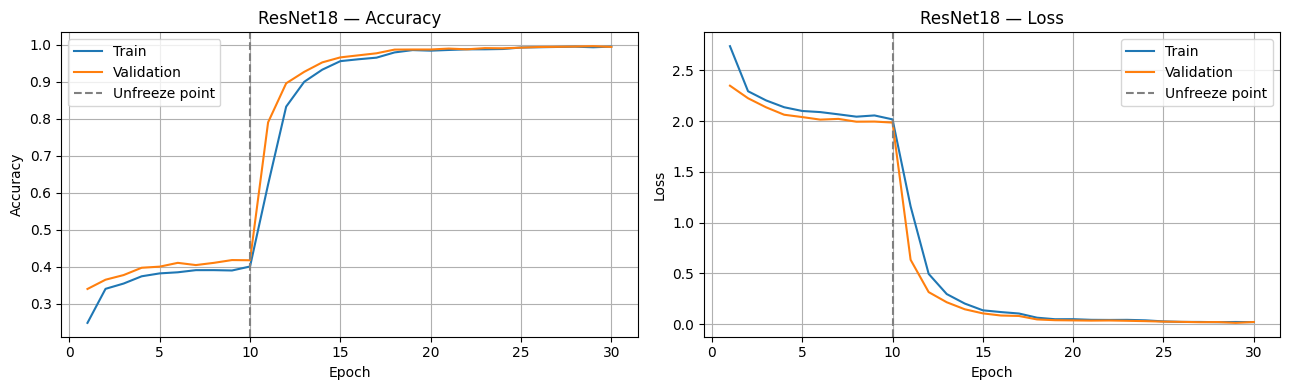

Saved: checkpoints/curves_resnet18.png

ResNet18 Test Accuracy: 0.8683

              precision    recall  f1-score   support

           0     0.6053    0.3833    0.4694        60
           1     0.8466    0.9042    0.8744       720
           2     0.8096    0.8333    0.8213       750
           3     0.7026    0.7822    0.7403       450
           4     0.9224    0.8288    0.8731       660
           5     0.6971    0.7889    0.7401       630
           6     0.9558    0.7200    0.8213       150
           7     0.9014    0.8333    0.8661       450
           8     0.7857    0.7822    0.7840       450
           9     0.9245    0.9437    0.9340       480
          10     0.9848    0.9788    0.9818       660
          11     0.9050    0.9071    0.9061       420
          12     0.9955    0.9725    0.9839       690
          13     0.9835    0.9958    0.9896       720
          14     0.9962    0.9593    0.9774       270
          15     1.0000    0.9619    0.9806       210
         

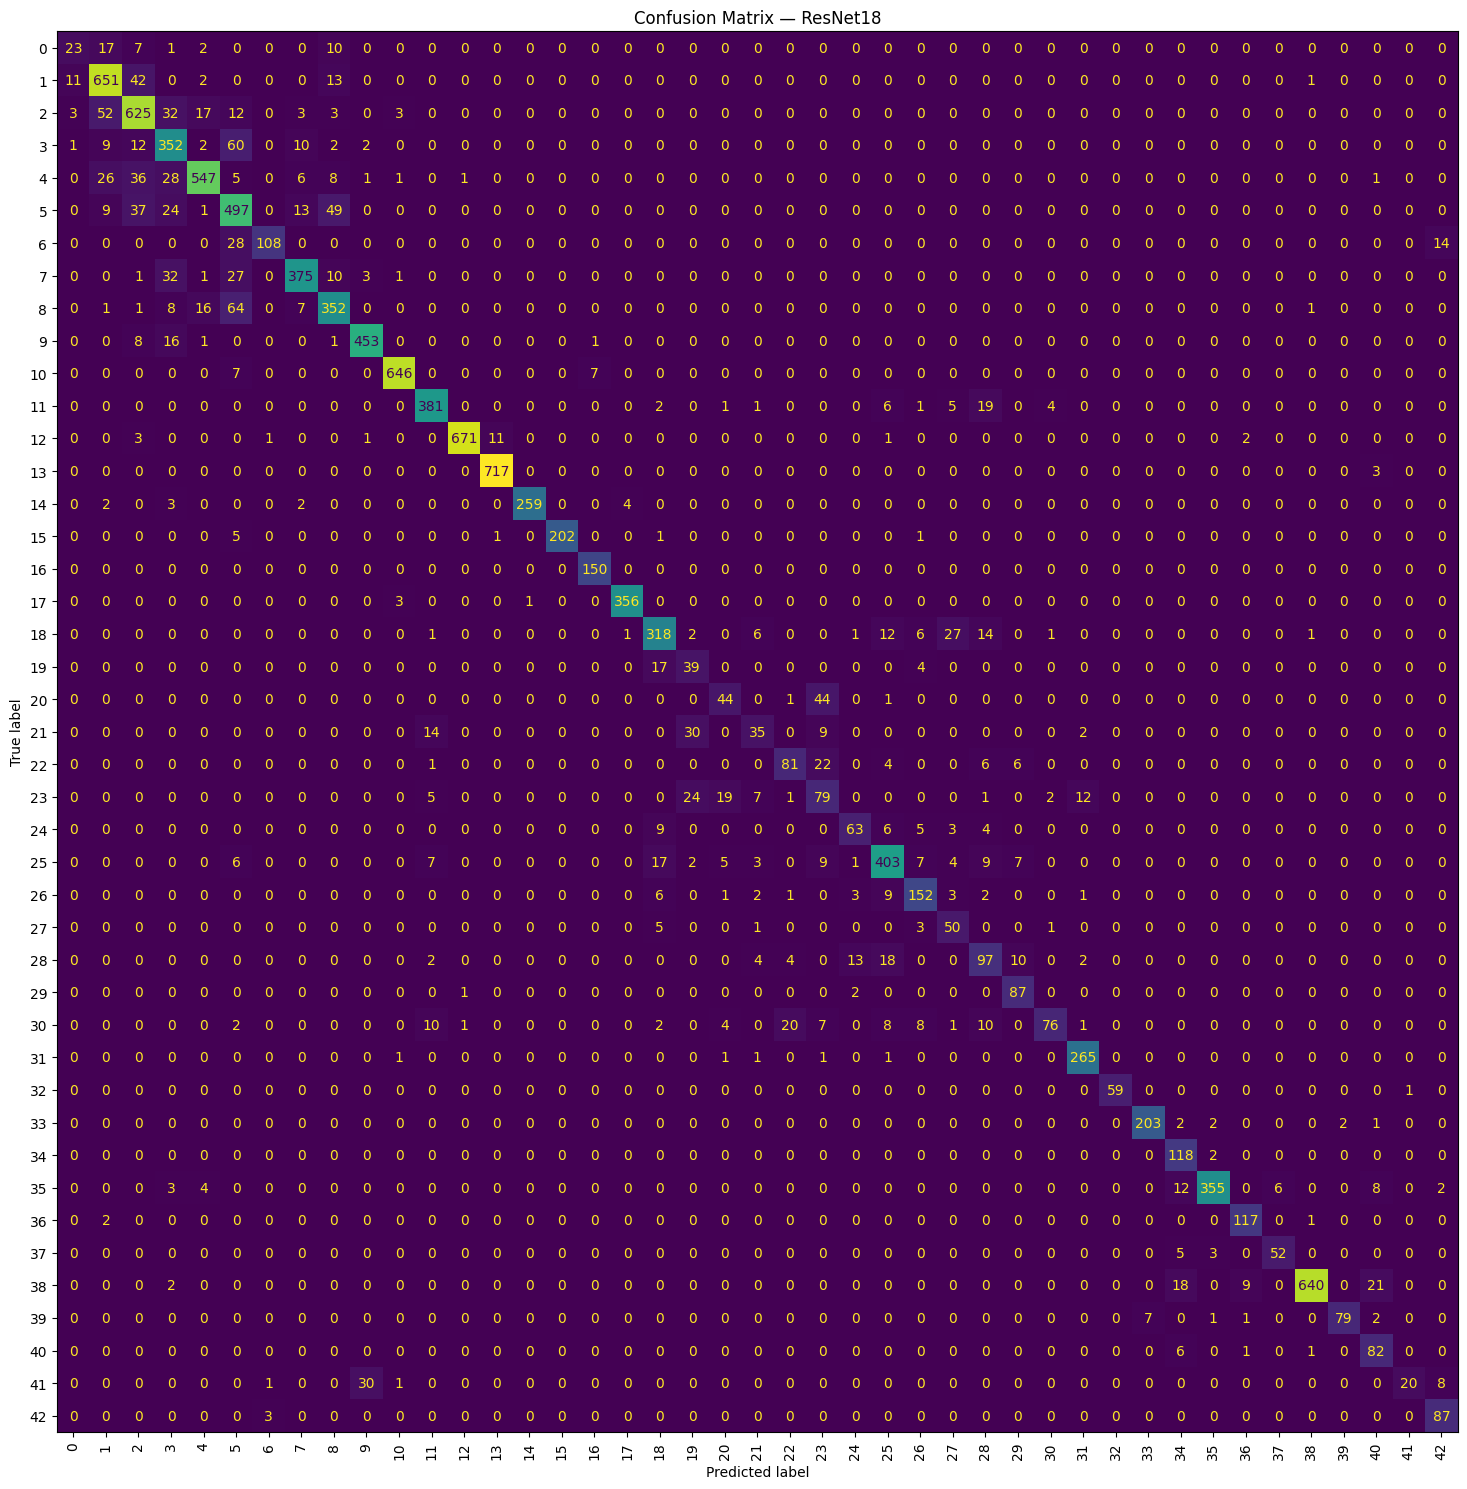

Saved: checkpoints/confusion_resnet18.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [ ]:
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── ResNet18 setup ────────────────────────────────────────────────
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all backbone layers
for p in resnet.parameters():
    p.requires_grad = False

# Replace final FC with 43-class head
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet = resnet.to(DEVICE)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"ResNet18 — Trainable parameters (frozen backbone): {trainable:,}")


# ── Phase 1: Train classifier head only (10 epochs) ──────────────
EPOCHS_P1    = 10
criterion_r  = nn.CrossEntropyLoss()
optimizer_r  = optim.Adam(resnet.fc.parameters(), lr=1e-3)

history_r    = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_r   = 0.0

print(f"\nPhase 1 — Head only, {EPOCHS_P1} epochs on {DEVICE}...\n")
for epoch in range(1, EPOCHS_P1 + 1):
    t0 = time.time()
    # reuse run_epoch but swap model/optimizer
    resnet.train()
    tl, tc, n = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_r.zero_grad()
        out  = resnet(imgs)
        loss = criterion_r(out, labels)
        loss.backward(); optimizer_r.step()
        tl += loss.item() * imgs.size(0)
        tc += (out.argmax(1) == labels).sum().item()
        n  += imgs.size(0)
    tr_loss, tr_acc = tl/n, tc/n

    resnet.eval()
    vl, vc, n = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = resnet(imgs)
            loss = criterion_r(out, labels)
            vl += loss.item() * imgs.size(0)
            vc += (out.argmax(1) == labels).sum().item()
            n  += imgs.size(0)
    vl_loss, vl_acc = vl/n, vc/n

    history_r["train_loss"].append(tr_loss)
    history_r["val_loss"].append(vl_loss)
    history_r["train_acc"].append(tr_acc)
    history_r["val_acc"].append(vl_acc)

    if vl_acc > best_val_r:
        best_val_r = vl_acc
        torch.save(resnet.state_dict(), "checkpoints/best_resnet18.pth")

    print(f"Epoch {epoch:02d}/{EPOCHS_P1} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f} | "
          f"{time.time()-t0:.1f}s")


# ── Phase 2: Unfreeze full network (20 epochs, lower LR) ─────────
for p in resnet.parameters():
    p.requires_grad = True

EPOCHS_P2   = 20
optimizer_r2 = optim.Adam(resnet.parameters(), lr=1e-4)
scheduler_r2 = optim.lr_scheduler.StepLR(optimizer_r2, step_size=7, gamma=0.5)

print(f"\nPhase 2 — Full fine-tune, {EPOCHS_P2} epochs...\n")
for epoch in range(1, EPOCHS_P2 + 1):
    t0 = time.time()
    resnet.train()
    tl, tc, n = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer_r2.zero_grad()
        out  = resnet(imgs)
        loss = criterion_r(out, labels)
        loss.backward(); optimizer_r2.step()
        tl += loss.item() * imgs.size(0)
        tc += (out.argmax(1) == labels).sum().item()
        n  += imgs.size(0)
    tr_loss, tr_acc = tl/n, tc/n

    resnet.eval()
    vl, vc, n = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = resnet(imgs)
            loss = criterion_r(out, labels)
            vl += loss.item() * imgs.size(0)
            vc += (out.argmax(1) == labels).sum().item()
            n  += imgs.size(0)
    vl_loss, vl_acc = vl/n, vc/n
    scheduler_r2.step()

    history_r["train_loss"].append(tr_loss)
    history_r["val_loss"].append(vl_loss)
    history_r["train_acc"].append(tr_acc)
    history_r["val_acc"].append(vl_acc)

    if vl_acc > best_val_r:
        best_val_r = vl_acc
        torch.save(resnet.state_dict(), "checkpoints/best_resnet18.pth")

    print(f"Epoch {epoch:02d}/{EPOCHS_P2} | "
          f"Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} | "
          f"Val Loss {vl_loss:.4f} Acc {vl_acc:.4f} | "
          f"{time.time()-t0:.1f}s")

print(f"\nBest Val Accuracy (ResNet18): {best_val_r:.4f}")


# ── Curves ────────────────────────────────────────────────────────
total_eps = EPOCHS_P1 + EPOCHS_P2
ep_range  = range(1, total_eps + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(ep_range, history_r["train_acc"], label="Train")
ax1.plot(ep_range, history_r["val_acc"],   label="Validation")
ax1.axvline(x=EPOCHS_P1, color="gray", linestyle="--", label="Unfreeze point")
ax1.set_title("ResNet18 — Accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy"); ax1.legend(); ax1.grid(True)

ax2.plot(ep_range, history_r["train_loss"], label="Train")
ax2.plot(ep_range, history_r["val_loss"],   label="Validation")
ax2.axvline(x=EPOCHS_P1, color="gray", linestyle="--", label="Unfreeze point")
ax2.set_title("ResNet18 — Loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss"); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("checkpoints/curves_resnet18.png", dpi=150)
plt.show()
print("Saved: checkpoints/curves_resnet18.png")


# ── Test evaluation ───────────────────────────────────────────────
resnet.load_state_dict(torch.load("checkpoints/best_resnet18.pth", map_location=DEVICE))
resnet.eval()

all_preds_r, all_labels_r = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = resnet(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds_r.append(preds)
        all_labels_r.append(labels)

all_preds_r  = torch.cat(all_preds_r).numpy()
all_labels_r = torch.cat(all_labels_r).numpy()

test_acc_r = (all_preds_r == all_labels_r).mean()
print(f"\nResNet18 Test Accuracy: {test_acc_r:.4f}\n")
print(classification_report(all_labels_r, all_preds_r, digits=4))

cm_r = confusion_matrix(all_labels_r, all_preds_r)
fig, ax = plt.subplots(figsize=(18, 15))
ConfusionMatrixDisplay(cm_r).plot(ax=ax, colorbar=False, xticks_rotation=90)
ax.set_title("Confusion Matrix — ResNet18")
plt.tight_layout()
plt.savefig("checkpoints/confusion_resnet18.png", dpi=150)
plt.show()
print("Saved: checkpoints/confusion_resnet18.png")


# ── Download ──────────────────────────────────────────────────────
from google.colab import files
for f in ["checkpoints/curves_resnet18.png",
          "checkpoints/confusion_resnet18.png",
          "checkpoints/best_resnet18.pth"]:
    files.download(f)
print("Done!")